# Признаки, модели и выбор решения

Сравниваю модели по официальной Precision@Recall≥0.70.
Основные эксперименты  на двух временных разбиениях, 17–19 апреля оставляю для контрольной диагностики.
Этот контроль уже просматривался при разработке, поэтому не считаю его полностью независимым тестом.

Здесь пересчитываются baseline и основные варианты, из которых было выбрано текущее решение.
Окончательный ансамбль уже зафиксирован; этот ноутбук не меняет параметры в `03_solution.ipynb`.

In [1]:
from pathlib import Path
import sys
import platform

import numpy as np
import pandas as pd

ROOT = Path.cwd()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
sys.path.insert(0, str(ROOT))
DATA = ROOT / "data"
OUTPUTS = ROOT / "outputs"
SEED = 2026
THREADS = 4

from features import META, MISSING, prepare_events, get_event_names, make_features

print("Python", platform.python_version())

import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from threadpoolctl import threadpool_limits
from IPython.display import display

from features import basic_features
from metric import precision_at_recall, recall_at_fpr, pr_curve

Python 3.13.5


## Данные и временные разбиения

In [2]:
def read_meta(filename):
    frame = pd.read_csv(DATA / filename, dtype={"cookie_id": str})
    for column in META[1:]:
        frame[column] = pd.to_datetime(frame[column], utc=True)
    return frame

train = read_meta("train.csv")
train = train.sort_values(["window_start_ts", "cookie_id"], kind="stable").reset_index(drop=True)
test = read_meta("test.csv")
raw_events = pd.read_csv(DATA / "events.csv.gz", dtype=str)
meta = pd.concat([train[META], test[META]], ignore_index=True)

pd.Series({"train": len(train), "test": len(test), "events": len(raw_events)}, name="rows")

train      11091
test        4909
events    328905
Name: rows, dtype: int64

In [3]:
assert train.cookie_id.notna().all() and train.cookie_id.is_unique
assert test.cookie_id.notna().all() and test.cookie_id.is_unique
assert set(train.cookie_id).isdisjoint(test.cookie_id)
assert train.target.notna().all() and set(train.target) == {0, 1}
assert "target" not in test
assert meta[META[1:]].notna().all().all()
assert (meta.window_end_ts - meta.window_start_ts).dt.total_seconds().eq(86400).all()
assert (meta.cookie_created_at < meta.window_end_ts).all()
assert train.window_end_ts.max() <= test.window_start_ts.min()

print("Идентификаторы, разметка и окна наблюдения в порядке")

Идентификаторы, разметка и окна наблюдения в порядке


In [4]:
splits = [
    ("2026-04-11", "2026-04-14"),
    ("2026-04-14", "2026-04-17"),
]
holdout = ("2026-04-17", "2026-04-20")

def split_meta(start, stop):
    start = pd.Timestamp(start, tz="UTC")
    stop = pd.Timestamp(stop, tz="UTC")
    fit = train.loc[(train.window_start_ts < start) & (train.window_end_ts <= start)]
    valid = train.loc[(train.window_start_ts >= start) & (train.window_start_ts < stop)]
    assert set(fit.cookie_id).isdisjoint(valid.cookie_id)
    assert fit.window_end_ts.max() <= valid.window_start_ts.min()
    assert fit.target.nunique() == valid.target.nunique() == 2
    return fit, valid

split_rows = []
for start, stop in splits + [holdout]:
    fit, valid = split_meta(start, stop)
    split_rows.append({
        "Валидация с": start,
        "До, не включая": stop,
        "Train": len(fit),
        "Validation": len(valid),
        "Положительных в validation": int(valid.target.sum()),
    })
pd.DataFrame(split_rows)

,Валидация с,"До, не включая",Train,Validation,Положительных в validation
0,2026-04-11,2026-04-14,4217,2556,199
1,2026-04-14,2026-04-17,6773,2367,195
2,2026-04-17,2026-04-20,9140,1951,160


В каждом разбиении обучаюсь только на завершившихся окнах из прошлого.
Последний период не использовался для выбора текущих параметров.
После проверки финальные модели обучаются на всём train.

## Метрика

`metric.py` содержит расчёт из выданного файла. Проверки входов и самопроверки перенесены в ноутбук.
При одинаковых score группа включается целиком. Среди всех порогов с recall ≥ 70% берётся максимальный precision,
а не обязательно первая точка достижения требуемого recall.

In [5]:
assert precision_at_recall([1, 0, 1, 1, 1], [5, 4, 3, 2, 1]) == 0.8
assert precision_at_recall([1, 1, 0, 0], [0.5] * 4) == 0.5
assert precision_at_recall([0, 0, 1, 1], [0.5] * 4) == 0.5
assert recall_at_fpr([1] * 10 + [0] * 90, [0.5] * 100) == 0.0


def evaluate(y, score):
    y = np.asarray(y, dtype=int)
    score = np.asarray(score, dtype=float)
    assert y.shape == score.shape
    assert set(y) == {0, 1}
    assert np.isfinite(score).all()
    return {
        "P@R≥0.70": precision_at_recall(y, score),
        "AP": average_precision_score(y, score),
        "ROC-AUC": roc_auc_score(y, score),
        "R@FPR≤0.01": recall_at_fpr(y, score),
    }

## Наборы признаков

Baseline из quickstart  RandomForest на числе событий и уникальных объявлений.
Для него отдельно проверяю вариант без удаления дублей и с удалением.

Затем сравниваю прежние 414 признаков с полным набором из 597.
Новые 183 признака описывают регулярность сессий, концентрацию интересов,
относительную геометрию курсора и покрытие поисковых страниц.
Отдельно проверяю только новый временной блок и сокращённый набор признаков.

In [6]:
events = prepare_events(raw_events, train)
raw_in_window = prepare_events(raw_events, train, deduplicate=False)
vocabulary_train = train.loc[train.window_end_ts <= pd.Timestamp("2026-04-11", tz="UTC")]
event_names = get_event_names(vocabulary_train, events)
X = make_features(train[META], events, event_names, n_jobs=THREADS)

base_columns = [column for column in X if not column.startswith(("ptr_", "ex_", "norm_", "v3_"))]
extra_columns = [column for column in X if column.startswith("ex_")]
context_columns = [column for column in X if column.startswith("norm_")]
new_columns = [column for column in X if column.startswith("v3_")]
previous_columns = [column for column in X if not column.startswith("v3_")]
rhythm_columns = [column for column in new_columns if column.startswith(("v3_s", "v3_gap_"))]

compact_base = [column for column in base_columns if not (
    column.startswith(("hour_", "query_length_", "query_words_", "transition_", "session_"))
    or column.endswith(("_hhi", "_n_observed", "_top_share", "_p10", "_p90", "_min", "_max"))
)]
compact_extra = [column for column in extra_columns if not (
    "_within30_" in column or "_within120_" in column or "_within1800_" in column
    or column.endswith(("_std", "_p25", "_p75", "_p95", "_count"))
)]

matrices = {
    "baseline_raw": basic_features(train, raw_in_window),
    "baseline_clean": basic_features(train, events),
    "behavior": X[base_columns],
    "previous": X[previous_columns],
    "full": X,
    "rhythm": X[previous_columns + rhythm_columns],
    "compact": X[compact_base + compact_extra + context_columns + new_columns],
}
pd.Series({name: frame.shape[1] for name, frame in matrices.items()}, name="Признаки")

baseline_raw        2
baseline_clean      2
behavior          174
previous          414
full              597
rhythm            531
compact           401
Name: Признаки, dtype: int64

Общий набор агрегатов можно посчитать один раз: они не используют target и не смешивают разные куки.
Словарь типов событий определён только на 6–10 апреля. Категории LightGBM задаются заново на обучающей части каждого разбиения.

In [7]:
assert not {"target", "cookie_id", "item_id", "user_agent", "search_query"} & set(X.columns)
assert X.index.is_unique
assert not np.isinf(X.select_dtypes("number").to_numpy()).any()

pd.DataFrame({
    "Пропуски": X.isna().mean(),
    "Число уникальных значений": X.nunique(),
}).sort_values("Пропуски", ascending=False).head(12)

,Пропуски,Число уникальных значений
ex_item_view_query_entropy,1.000000,0
ex_item_view_query_unique_share,1.000000,0
ex_item_view_query_top_share,1.000000,0
ex_search_results_view_item_top_share,1.000000,0
ex_search_results_view_item_entropy,1.000000,0
ex_search_results_view_item_unique_share,1.000000,0
ex_messages_per_chat,0.769272,22
search_page_forward_share,0.717970,33
search_page_step1_share,0.717970,27
v3_ptr_turn_cos_q10,0.687224,3469


## Модели

Параметры заданы явно. Не использую раннюю остановку по контрольному периоду.
Веса классов, более сильную регуляризацию и сокращение признаков проверяю как отдельные варианты.

In [8]:
rf_params = dict(n_estimators=300, min_samples_leaf=3, random_state=0, n_jobs=THREADS)
lgb_params = dict(
    n_estimators=500, num_leaves=15, min_child_samples=30,
    learning_rate=0.03, reg_lambda=10, colsample_bytree=0.85,
)
cat_params = dict(iterations=800, depth=5, learning_rate=0.035, l2_leaf_reg=20)

experiments = {
    "RF, исходные события": ("rf", "baseline_raw", rf_params),
    "RF, без дублей": ("rf", "baseline_clean", rf_params),
    "CatBoost, 174 признака": (
        "cat", "behavior", dict(iterations=600, depth=5, learning_rate=0.05, l2_leaf_reg=10),
    ),
    "LightGBM, 414 признаков": ("lgb", "previous", lgb_params),
    "LightGBM, 597 признаков": ("lgb", "full", lgb_params),
    "CatBoost, 597 признаков": ("cat", "full", cat_params),
    "LightGBM, только новый ритм": ("lgb", "rhythm", lgb_params),
    "LightGBM, сокращённые признаки": (
        "lgb", "compact", dict(n_estimators=700, num_leaves=15, min_child_samples=40,
                                learning_rate=0.025, reg_lambda=15, colsample_bytree=0.9),
    ),
    "LightGBM, сильнее регуляризация": (
        "lgb", "full", dict(n_estimators=900, num_leaves=7, min_child_samples=60,
                             learning_rate=0.025, reg_lambda=20, colsample_bytree=0.9),
    ),
    "LightGBM, вес класса 2": (
        "lgb", "full", dict(n_estimators=700, num_leaves=15, min_child_samples=40,
                             learning_rate=0.025, reg_lambda=20, colsample_bytree=0.85,
                             scale_pos_weight=2),
    ),
}


def fit_predict(family, params, x_train, y_train, x_valid):
    x_train = x_train.copy()
    x_valid = x_valid.copy()
    categorical = x_train.select_dtypes("object").columns.tolist()
    if family == "rf":
        model = RandomForestClassifier(**params)
    elif family == "cat":
        model = CatBoostClassifier(
            **params, loss_function="Logloss", cat_features=categorical,
            random_seed=SEED, thread_count=THREADS, verbose=False,
            allow_writing_files=False,
        )
    else:
        for column in categorical:
            values = sorted(x_train[column].dropna().unique())
            x_train[column] = pd.Categorical(x_train[column], categories=values)
            x_valid[column] = pd.Categorical(x_valid[column], categories=values)
        model = LGBMClassifier(
            **params, random_state=SEED, n_jobs=THREADS,
            deterministic=True, force_col_wise=True, verbosity=-1,
        )
    with threadpool_limits(limits=THREADS):
        model.fit(x_train, np.asarray(y_train, dtype=int))
        score = model.predict_proba(x_valid)[:, 1]
    return score, model

## Development: сравнение на двух периодах

In [9]:
results = []
for start, stop in splits:
    fit, valid = split_meta(start, stop)
    predictions = {}
    for name, (family, block, params) in experiments.items():
        matrix = matrices[block]
        predictions[name], _ = fit_predict(
            family, params, matrix.loc[fit.cookie_id], fit.target, matrix.loc[valid.cookie_id]
        )
    predictions["Ансамбль 0.5 / 0.5"] = (
        0.5 * predictions["LightGBM, 597 признаков"]
        + 0.5 * predictions["CatBoost, 597 признаков"]
    )
    for name, prediction in predictions.items():
        row = {"Период": start, "Модель": name, **evaluate(valid.target, prediction)}
        results.append(row)
    print("Завершён период", start)

results = pd.DataFrame(results)
comparison = results.pivot(index="Модель", columns="Период", values="P@R≥0.70")
comparison["Среднее"] = comparison.mean(axis=1)
comparison.sort_values("Среднее", ascending=False).round(6)

Завершён период 2026-04-11


Завершён период 2026-04-14


Период,2026-04-11,2026-04-14,Среднее
Модель,,,
Ансамбль 0.5 / 0.5,0.654206,0.695431,0.674819
"LightGBM, сокращённые признаки",0.630631,0.709845,0.670238
"LightGBM, 597 признаков",0.636364,0.665049,0.650706
"LightGBM, сильнее регуляризация",0.587500,0.658654,0.623077
"LightGBM, вес класса 2",0.585062,0.631336,0.608199
"LightGBM, 414 признаков",0.578512,0.631336,0.604924
"CatBoost, 597 признаков",0.520446,0.665072,0.592759
"CatBoost, 174 признака",0.555556,0.554656,0.555106
"LightGBM, только новый ритм",0.526316,0.566116,0.546216


Лучший из приведённых вариантов  среднее LightGBM и CatBoost на 597 признаках.
У него 0.654206 и 0.695431 на двух периодах, среднее  0.674819.
Предыдущий LightGBM на 414 признаках давал среднее 0.604924.

Только новые временные признаки не помогли: среднее 0.546216.
Значит, результат не сводится к одной гипотезе про регулярность ботов.
Сокращённый набор оказался близок к ансамблю, но не обошёл его.

In [10]:
results.groupby("Модель")[["P@R≥0.70", "AP", "ROC-AUC"]].mean().sort_values("P@R≥0.70", ascending=False).round(6)

,P@R≥0.70,AP,ROC-AUC
Модель,,,
Ансамбль 0.5 / 0.5,0.674819,0.747947,0.921377
"LightGBM, сокращённые признаки",0.670238,0.741097,0.917810
"LightGBM, 597 признаков",0.650706,0.741052,0.917061
"LightGBM, сильнее регуляризация",0.623077,0.734497,0.916519
"LightGBM, вес класса 2",0.608199,0.739473,0.916177
"LightGBM, 414 признаков",0.604924,0.719885,0.904753
"CatBoost, 597 признаков",0.592759,0.738014,0.919118
"CatBoost, 174 признака",0.555106,0.704952,0.905918
"LightGBM, только новый ритм",0.546216,0.712524,0.897350


При разработке также проверялись другие числа деревьев, HistGradientBoosting,
случайные пороги LightGBM, усреднение трёх seed и несколько фиксированных смесей.
Они не обошли выбранный ансамбль. Полный ExtraTreesClassifier был остановлен из-за стоимости расчёта
и в выборе не участвовал. Поиск был последовательным по development, а не заранее независимым экспериментом.

## Контрольная диагностика: 17–19 апреля

На этом этапе решение уже выбрано. Сравниваю его с baseline и предыдущей моделью,
но не использую результат для новой настройки.

In [11]:
fit, valid = split_meta(*holdout)
hold_predictions = {}
hold_models = {}
for name in ["RF, исходные события", "LightGBM, 414 признаков", "LightGBM, 597 признаков", "CatBoost, 597 признаков"]:
    family, block, params = experiments[name]
    hold_predictions[name], hold_models[name] = fit_predict(
        family, params, matrices[block].loc[fit.cookie_id], fit.target, matrices[block].loc[valid.cookie_id]
    )
hold_predictions["Ансамбль 0.5 / 0.5"] = (
    0.5 * hold_predictions["LightGBM, 597 признаков"]
    + 0.5 * hold_predictions["CatBoost, 597 признаков"]
)
shown = ["RF, исходные события", "LightGBM, 414 признаков", "Ансамбль 0.5 / 0.5"]
hold_metrics = pd.DataFrame({name: evaluate(valid.target, hold_predictions[name]) for name in shown}).T
hold_metrics.round(6)

,P@R≥0.70,AP,ROC-AUC,R@FPR≤0.01
"RF, исходные события",0.108213,0.179297,0.608707,0.07500
"LightGBM, 414 признаков",0.592593,0.710775,0.908979,0.51875
Ансамбль 0.5 / 0.5,0.654971,0.748541,0.929306,0.51875


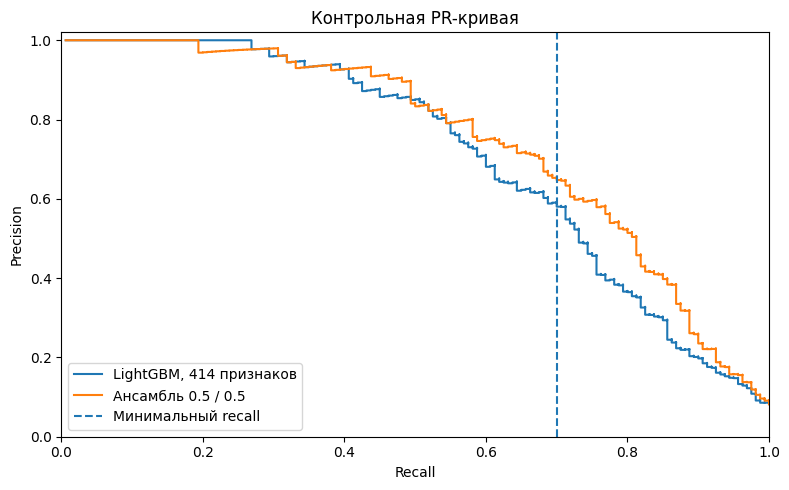

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
for name in ["LightGBM, 414 признаков", "Ансамбль 0.5 / 0.5"]:
    precision, recall = pr_curve(valid.target, hold_predictions[name])
    ax.step(recall, precision, where="post", label=name)
ax.axvline(0.7, linestyle="--", label="Минимальный recall")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Контрольная PR-кривая")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend()
fig.tight_layout()
plt.show()

In [13]:
def error_counts(y, score):
    y = np.asarray(y, dtype=int)
    score = np.asarray(score)
    order = np.argsort(-score, kind="stable")
    ordered_scores = score[order]
    ends = np.flatnonzero(np.r_[ordered_scores[1:] != ordered_scores[:-1], True])
    precision, recall = pr_curve(y, score)
    allowed = np.flatnonzero(recall >= 0.7)
    best = allowed[np.argmax(precision[allowed])]
    threshold = ordered_scores[ends[best]]
    predicted = score >= threshold
    return {
        "Precision": precision[best],
        "Recall": recall[best],
        "TP": int(np.sum(predicted & (y == 1))),
        "FP": int(np.sum(predicted & (y == 0))),
        "FN": int(np.sum(~predicted & (y == 1))),
    }

pd.DataFrame({
    name: error_counts(valid.target, hold_predictions[name])
    for name in ["LightGBM, 414 признаков", "Ансамбль 0.5 / 0.5"]
}).T

,Precision,Recall,TP,FP,FN
"LightGBM, 414 признаков",0.592593,0.7,112.0,77.0,48.0
Ансамбль 0.5 / 0.5,0.654971,0.7,112.0,59.0,48.0


При recall 70% обе модели находят 112 положительных куки.
Ансамбль даёт 59 ложных срабатываний вместо 77; precision растёт с 0.592593 до 0.654971.
AP и ROC-AUC тоже выросли, а recall при FPR ≤ 1% остался тем же.

Это диагностический результат на 160 положительных куки, а не гарантия качества на новых источниках трафика.
Ранее рассчитанный парный bootstrap для разницы основной метрики дал 95%-й интервал примерно от −0.011 до 0.204:
данных недостаточно, чтобы уверенно исключить отсутствие выигрыша.

## Какие признаки использует модель

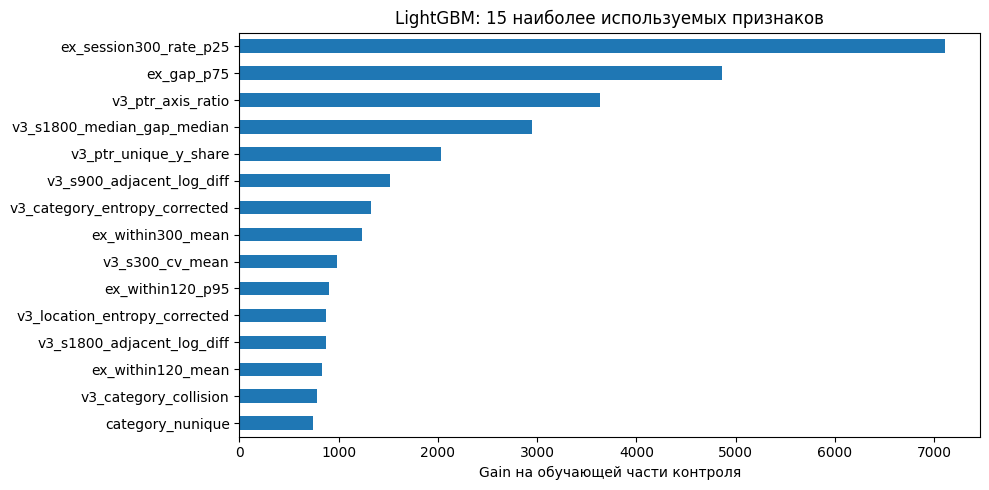

In [14]:
model = hold_models["LightGBM, 597 признаков"]
importance = pd.Series(model.booster_.feature_importance(importance_type="gain"), index=X.columns)
importance = importance.sort_values().tail(15)

fig, ax = plt.subplots(figsize=(10, 5))
importance.plot.barh(ax=ax)
ax.set_xlabel("Gain на обучающей части контроля")
ax.set_title("LightGBM: 15 наиболее используемых признаков")
fig.tight_layout()
plt.show()

Помимо временных характеристик, модель использует относительную геометрию курсора и повторяемость интересов.
Gain  внутренняя важность разбиений, а не причинный эффект и не оценка надёжности признака на другом трафике.

## Итог

Оставляю **LightGBM + CatBoost, веса 0.5 / 0.5**, без порога и дополнительных поправок.
Итоговое обучение и создание файла  в `03_solution.ipynb`.

Для этой версии получен результат **0.76000 на Stepik**; константный ответ  **0.09391**.
Эти два числа относятся к отправке на платформу и здесь не пересчитываются.
Форматирование проекта не меняет модель или её предсказания.